In [2]:
!pip install pandas matplotlib seaborn plotly fredapi lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=d6e399d46e22d205e066949defa51b4927c2ec9f8aa64797de27473528abc017
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from fredapi import Fred
import plotly.express as px
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

fred = Fred(api_key='e956a3dbccd7d4f90be734f8d55b1d07')

# Features and Target
series_ids = {
    'RSAFS': 'Retail Sales: All Food Services (Target)',
    'CPIAUCSL': 'Consumer Price Index',
    'UNRATE': 'Unemployment Rate',
    'FEDFUNDS': 'Federal Funds Rate',
    'PCE': 'Personal Consumption Expenditures',
    'DSPIC96': 'Real Disposable Personal Income'
}

# Data from FRED
data = pd.DataFrame()
for series_id in series_ids:
    data[series_id] = fred.get_series(series_id)

data.index = fred.get_series('RSAFS').index

data.dropna(inplace=True)

data.rename(columns=series_ids, inplace=True)

data.reset_index(inplace=True)
data.rename(columns={'index': 'ds', 'Retail Sales: All Food Services (Target)': 'y'}, inplace=True)

Data shape: (394, 25)
First few rows of the dataset:
          ds         y  Consumer Price Index  Unemployment Rate  \
5 1992-06-01  161205.0                 140.1                7.8   
6 1992-07-01  162855.0                 140.5                7.7   
7 1992-08-01  162412.0                 140.8                7.6   
8 1992-09-01  164361.0                 141.1                7.6   
9 1992-10-01  166063.0                 141.7                7.3   

   Federal Funds Rate  Personal Consumption Expenditures  \
5                3.76                             4177.1   
6                3.25                             4204.8   
7                3.30                             4220.9   
8                3.22                             4255.3   
9                3.10                             4284.7   

   Real Disposable Personal Income  month  quarter  year  ...  \
5                           7601.6      6        2  1992  ...   
6                           7595.9      7        3  1

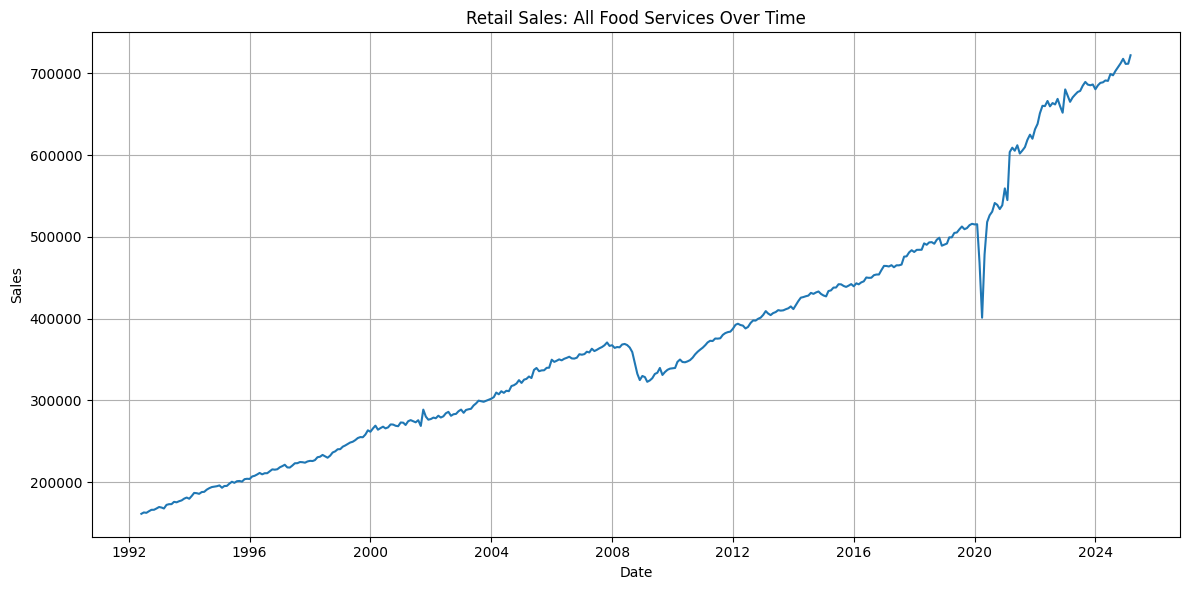

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0525 - val_loss: 0.1509
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0242 - val_loss: 0.0629
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0098 - val_loss: 0.0144
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0085 - val_loss: 0.0135
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0051 - val_loss: 0.0207
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0037 - val_loss: 0.0117
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0025 - val_loss: 0.0032
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0024 - val_loss: 0.0023
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0022 - val_loss: 0.0027
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0017 - val_loss: 0.0018
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0016 - val_loss: 3.9120e-04
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0017 - val_loss: 0.00

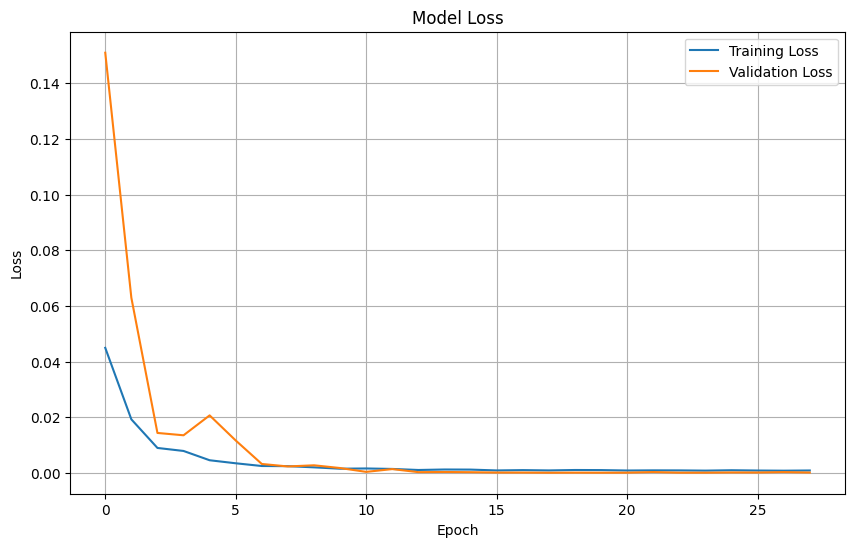

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Mean Absolute Error: $28633.16 million
Mean Squared Error: $1119603217.62 million
Root Mean Squared Error: $33460.47 million
R-squared: 0.8354


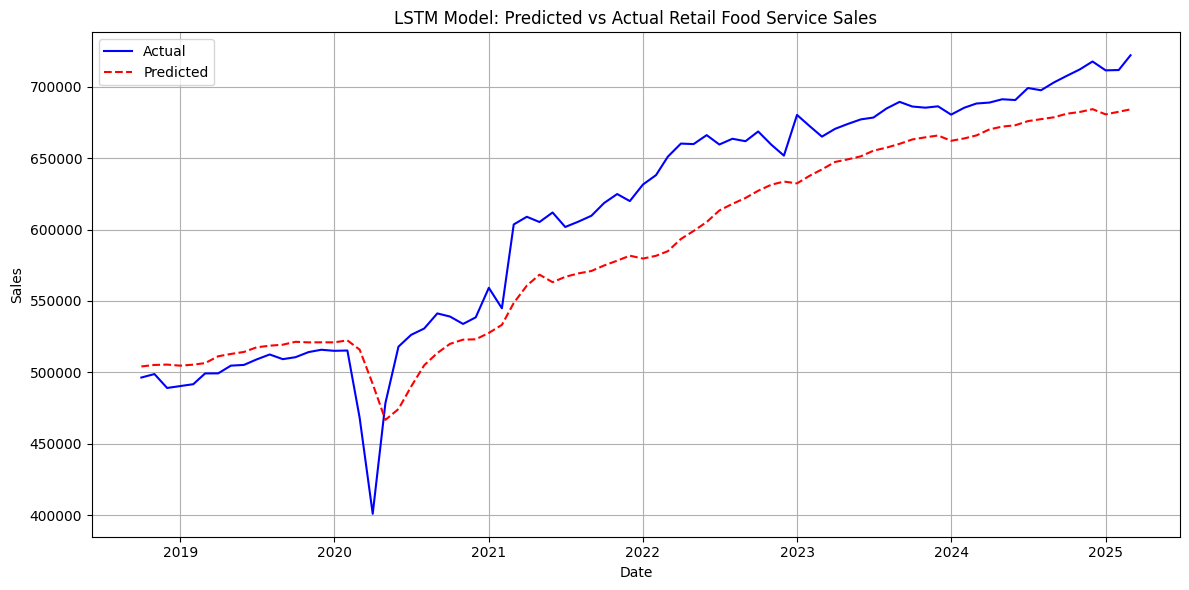

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import shap
import lime
import lime.lime_tabular
from datetime import timedelta

np.random.seed(42)
tf.random.set_seed(42)

print("Data shape:", data.shape)
print("First few rows of the dataset:")
print(data.head())
print("Data info:")
print(data.info())
print("Summary statistics:")
print(data.describe())

print("Missing values:")
print(data.isnull().sum())

# Plot the target variable
plt.figure(figsize=(12, 6))
plt.plot(data['ds'], data['y'])
plt.title('Retail Sales: All Food Services Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

# Feature Engineering
# Create time-based features
data['month'] = data['ds'].dt.month
data['quarter'] = data['ds'].dt.quarter
data['year'] = data['ds'].dt.year

# lag features for the target variable
for lag in range(1, 4):
    data[f'y_lag_{lag}'] = data['y'].shift(lag)

# lag features for the external regressors
external_regressors = ['Consumer Price Index', 'Unemployment Rate',
                      'Federal Funds Rate', 'Personal Consumption Expenditures',
                      'Real Disposable Personal Income']

for feature in external_regressors:
    for lag in range(1, 3):
        data[f'{feature}_lag_{lag}'] = data[feature].shift(lag)

# rolling mean features
data['y_rolling_mean_3'] = data['y'].rolling(window=3).mean()
data['y_rolling_mean_6'] = data['y'].rolling(window=6).mean()

data.dropna(inplace=True)

features = [col for col in data.columns if col not in ['ds', 'y']]
X = data[features].values
y = data['y'].values

# Normalize
X_scaler = MinMaxScaler(feature_range=(0, 1))
y_scaler = MinMaxScaler(feature_range=(0, 1))

X_scaled = X_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y.reshape(-1, 1))

train_size = int(len(X_scaled) * 0.8)
X_train, X_test = X_scaled[:train_size], X_scaled[train_size:]
y_train, y_test = y_scaled[:train_size], y_scaled[train_size:]

X_train_reshaped = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_reshaped = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(1, X_train.shape[1])))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_reshaped, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# training & validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()

# predictions
y_pred_scaled = model.predict(X_test_reshaped)
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_test_actual = y_scaler.inverse_transform(y_test)

# Evaluation
mae = mean_absolute_error(y_test_actual, y_pred)
mse = mean_squared_error(y_test_actual, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred)

print(f"Mean Absolute Error: ${mae:.2f} million")
print(f"Mean Squared Error: ${mse:.2f} million")
print(f"Root Mean Squared Error: ${rmse:.2f} million")
print(f"R-squared: {r2:.4f}")

# Visualize predictions vs. actual values
test_dates = data['ds'].iloc[train_size:].reset_index(drop=True)

plt.figure(figsize=(12, 6))
plt.plot(test_dates, y_test_actual, label='Actual', color='blue')
plt.plot(test_dates, y_pred, label='Predicted', color='red', linestyle='--')
plt.title('LSTM Model: Predicted vs Actual Retail Food Service Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
3/3 ━━━━━━━━

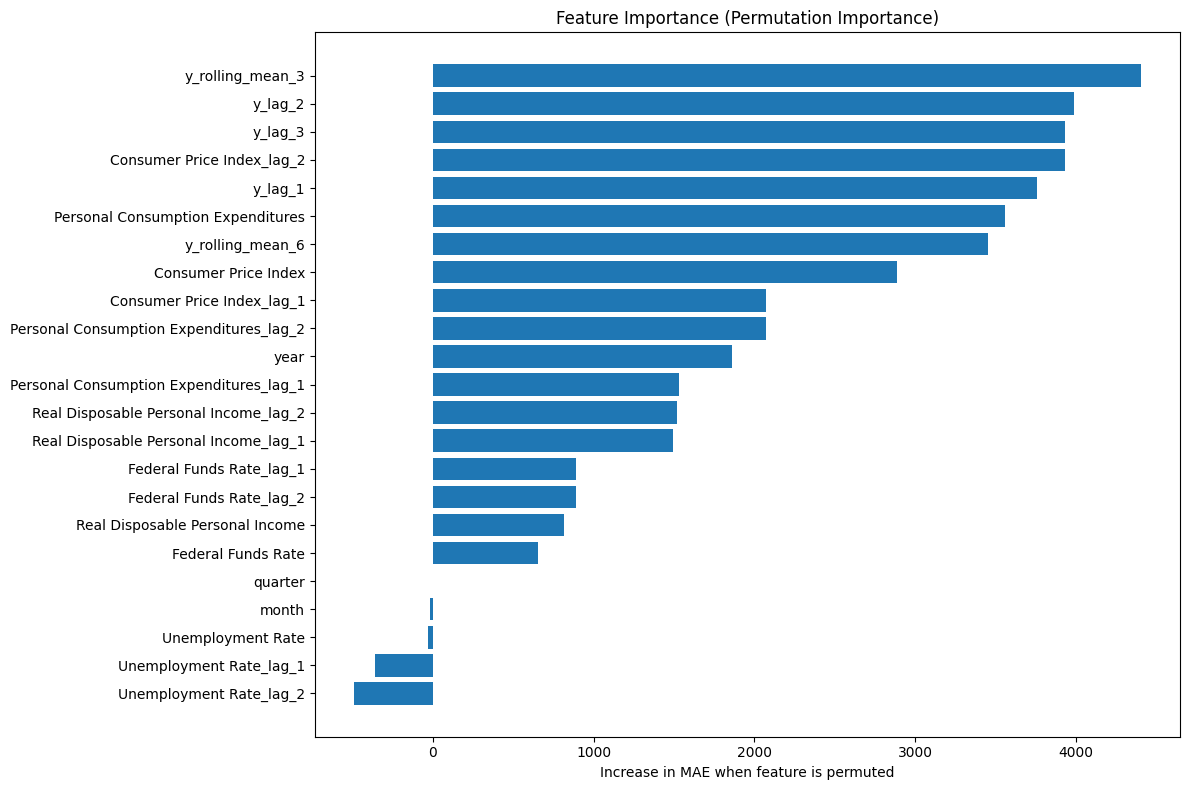

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
6544/6544 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
6544/6544 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
6544/6544 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
6544/6544 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
6544/6544 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
6544/6544 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
6544/6544 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
6544/6544 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
6544/6544 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
6544/6544 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
6544/6544 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
6544/6544 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━

TypeError: only integer scalar arrays can be converted to a scalar index

<Figure size 1200x800 with 0 Axes>

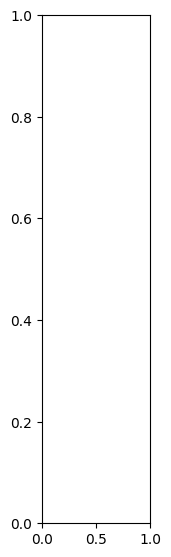

In [7]:
# 1. Feature Importance using permutation importance
def permutation_importance(model, X, y, n_repeats=10):
    baseline_mae = mean_absolute_error(
        y_scaler.inverse_transform(y),
        y_scaler.inverse_transform(model.predict(X.reshape(X.shape[0], 1, X.shape[1])))
    )

    importances = []
    for i in range(X.shape[1]):
        scores = []
        for _ in range(n_repeats):
            X_permuted = X.copy()
            # Permute the i-th feature
            np.random.shuffle(X_permuted[:, i])
            X_permuted_reshaped = X_permuted.reshape((X_permuted.shape[0], 1, X_permuted.shape[1]))

            # Calculate MAE with permuted feature
            y_pred = model.predict(X_permuted_reshaped)
            permuted_mae = mean_absolute_error(
                y_scaler.inverse_transform(y),
                y_scaler.inverse_transform(y_pred)
            )
            # Calculate importance as increase in error
            scores.append(permuted_mae - baseline_mae)
        importances.append(np.mean(scores))

    return importances

importances = permutation_importance(model, X_test, y_test)

plt.figure(figsize=(12, 8))
sorted_idx = np.argsort(importances)
plt.barh(np.array(features)[sorted_idx], np.array(importances)[sorted_idx])
plt.xlabel('Increase in MAE when feature is permuted')
plt.title('Feature Importance (Permutation Importance)')
plt.tight_layout()
plt.show()

# 2. SHAP (SHapley Additive exPlanations) for LSTM

def f(X):
    X_reshaped = X.reshape(X.shape[0], 1, X.shape[1])
    return y_scaler.inverse_transform(model.predict(X_reshaped))

explainer = shap.KernelExplainer(f, X_train[:100])  # Use a subset for efficiency

shap_values = explainer.shap_values(X_test[:50])

print(f"SHAP values shape: {np.array(shap_values).shape}")
print(f"X_test[:50] shape: {X_test[:50].shape}")

# SHAP summary plot - Fix for shape mismatch
plt.figure(figsize=(12, 8))


if isinstance(shap_values, list):
    if shap_values[0].shape == X_test[:50].shape:
        shap.summary_plot(shap_values, X_test[:50], feature_names=features)
    else:
        shap.summary_plot(shap_values[0], X_test[:50], feature_names=features)
else:
    shap.summary_plot(shap_values, X_test[:50], feature_names=features)


# 3. Simple Feature Contribution Analysis
# This approach is more memory-efficient than LIME for LSTM models
def feature_contribution_analysis(model, X_sample, feature_names):

    # the base prediction
    X_sample_reshaped = X_sample.reshape(1, 1, -1)
    base_pred = y_scaler.inverse_transform(model.predict(X_sample_reshaped))[0, 0]

    # Calculate contribution of each feature
    contributions = []
    for i in range(X_sample.shape[0]):
        X_modified = X_sample.copy()
        X_modified[i] = 0
        X_modified_reshaped = X_modified.reshape(1, 1, -1)

        # Get prediction with feature zeroed
        modified_pred = y_scaler.inverse_transform(model.predict(X_modified_reshaped))[0, 0]

        # Contribution is the difference
        contribution = base_pred - modified_pred
        contributions.append((feature_names[i], contribution))

    # Sort by absolute contribution
    contributions.sort(key=lambda x: abs(x[1]), reverse=True)
    return contributions, base_pred

# Analyze a single prediction
observation_idx = 0  # First test observation
contributions, base_pred = feature_contribution_analysis(
    model,
    X_test[observation_idx],
    features
)

plt.figure(figsize=(10, 6))
top_n = 10
feature_names = [x[0] for x in contributions[:top_n]]
feature_values = [x[1] for x in contributions[:top_n]]
colors = ['green' if x > 0 else 'red' for x in feature_values]

plt.barh(range(top_n), feature_values[:top_n], color=colors)
plt.yticks(range(top_n), feature_names)
plt.xlabel('Contribution to Prediction')
plt.title(f'Feature Contributions for Prediction: ${base_pred:.2f} million')
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()


# 4. Partial Dependence Plots (PDPs)
# Create PDPs for selected features
important_features = np.argsort(importances)[-5:]  # Top 5 features

for feature_idx in important_features:
    feature_name = features[feature_idx]

    feature_values = np.linspace(
        np.min(X_test[:, feature_idx]),
        np.max(X_test[:, feature_idx]),
        20
    )

    # Calculate predictions for each value
    predictions = []
    for value in feature_values:
        X_modified = X_test.copy()
        X_modified[:, feature_idx] = value
        X_modified_reshaped = X_modified.reshape((X_modified.shape[0], 1, X_modified.shape[1]))
        pred = model.predict(X_modified_reshaped)
        predictions.append(y_scaler.inverse_transform(pred).mean())

    # Create a dummy array to unscale just this feature
    dummy = np.zeros((len(feature_values), X_test.shape[1]))
    dummy[:, feature_idx] = feature_values

    # Inverse transform to get original feature values
    unscaled_dummy = X_scaler.inverse_transform(dummy)
    unscaled_feature_values = unscaled_dummy[:, feature_idx]

    plt.figure(figsize=(8, 6))
    plt.plot(unscaled_feature_values, predictions)
    plt.title(f'Partial Dependence Plot for {feature_name}')
    plt.xlabel(feature_name)
    plt.ylabel('Predicted Sales')
    plt.grid(True)
    plt.show()

# 5. Feature Interaction Analysis
# Create interaction plots for top 2 features
top_features = np.argsort(importances)[-2:]
feature1_idx, feature2_idx = top_features[1], top_features[0]
feature1_name, feature2_name = features[feature1_idx], features[feature2_idx]

# this is a grid of values for both features
feature1_values = np.linspace(
    np.min(X_test[:, feature1_idx]),
    np.max(X_test[:, feature1_idx]),
    10
)
feature2_values = np.linspace(
    np.min(X_test[:, feature2_idx]),
    np.max(X_test[:, feature2_idx]),
    10
)

# predictions for each combination
interaction_matrix = np.zeros((len(feature1_values), len(feature2_values)))
for i, val1 in enumerate(feature1_values):
    for j, val2 in enumerate(feature2_values):
        X_modified = X_test.copy()
        X_modified[:, feature1_idx] = val1
        X_modified[:, feature2_idx] = val2
        X_modified_reshaped = X_modified.reshape((X_modified.shape[0], 1, X_modified.shape[1]))
        pred = model.predict(X_modified_reshaped)
        interaction_matrix[i, j] = y_scaler.inverse_transform(pred).mean()

plt.figure(figsize=(10, 8))
plt.imshow(interaction_matrix, cmap='viridis', aspect='auto')
plt.colorbar(label='Predicted Sales')
plt.title(f'Interaction between {feature1_name} and {feature2_name}')
plt.xlabel(feature2_name)
plt.ylabel(feature1_name)
plt.tight_layout()
plt.show()

# 6 Summary of model performance and key drivers
print("==== LSTM Model Performance and Insights Summary ====")
print(f"Model Performance:")
print(f"  - RMSE: ${rmse:.2f} million")
print(f"  - MAE: ${mae:.2f} million")
print(f"  - R-squared: {r2:.4f}")

print("Top 5 Most Important Features:")
top5_idx = np.argsort(importances)[-5:][::-1]
for i, idx in enumerate(top5_idx):
    print(f"  {i+1}. {features[idx]}: {importances[idx]:.4f}")


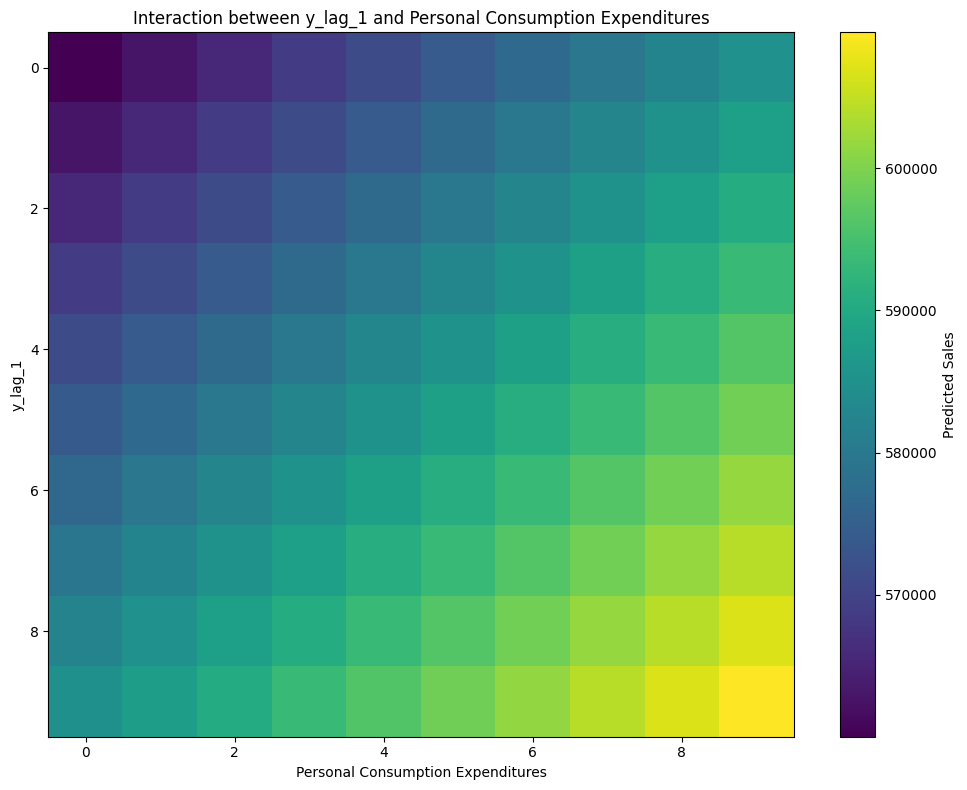


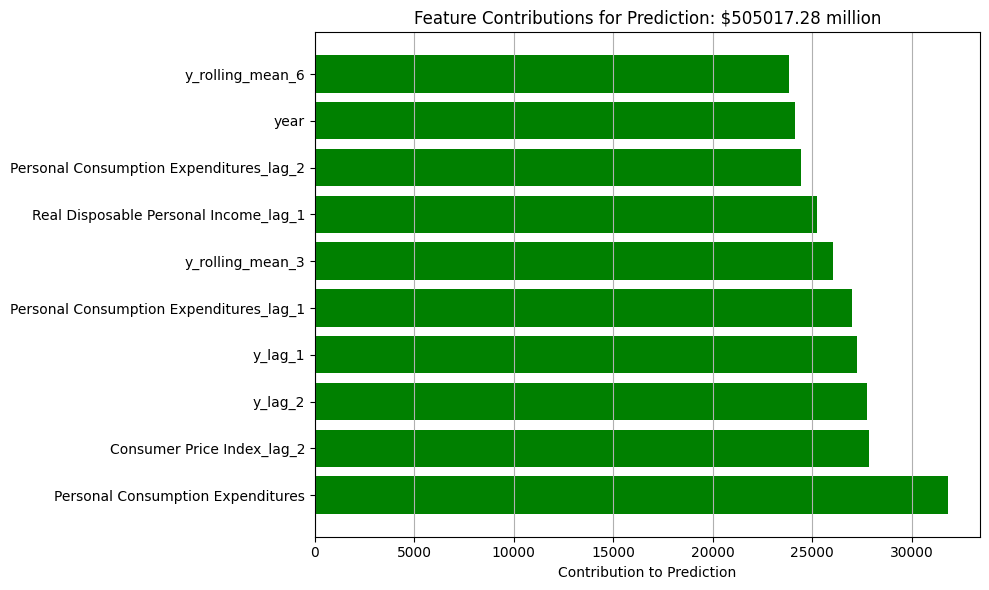

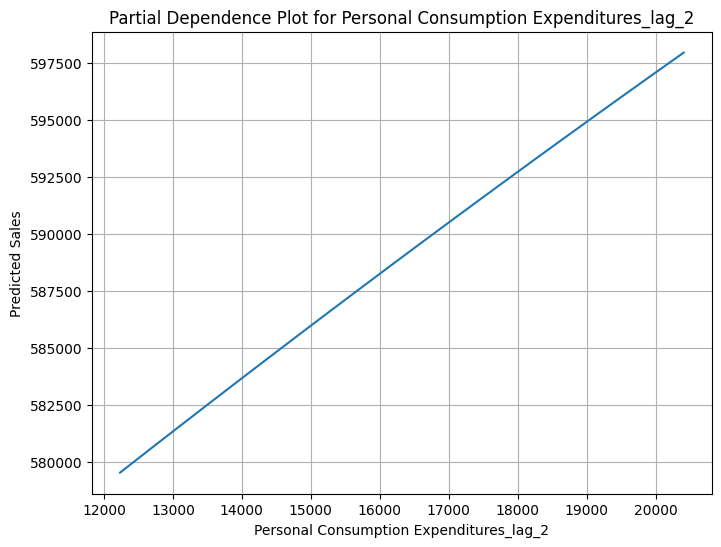

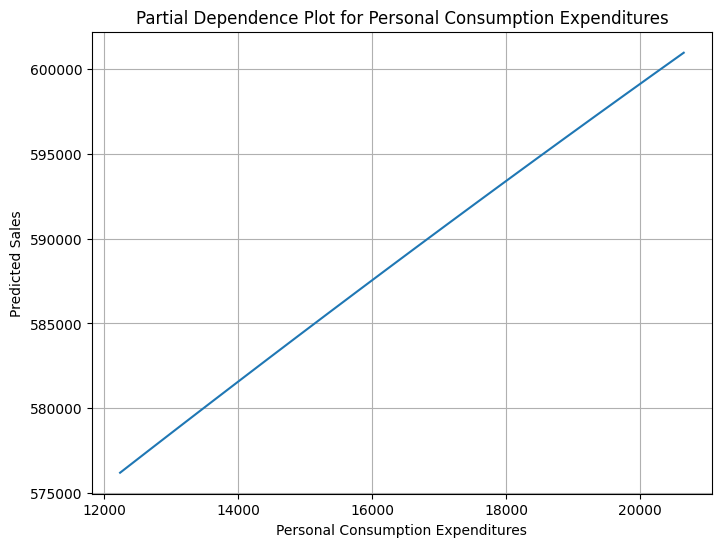


12-Month Forecast with Explanations:

Date: 2025-03
Forecasted Sales: $691533.12 million
Key Influences:
  - Personal Consumption Expenditures: positive impact of 48185.5000
  - y_lag_1: positive impact of 44634.3750
  - y_lag_2: positive impact of 41607.1875

Date: 2025-04
Forecasted Sales: $694526.38 million
Key Influences:
  - Personal Consumption Expenditures: positive impact of 48624.9375
  - y_lag_1: positive impact of 45000.1875
  - y_lag_2: positive impact of 41671.3125

Date: 2025-05
Forecasted Sales: $692550.88 million
Key Influences:
  - Personal Consumption Expenditures: positive impact of 48892.2500
  - y_lag_1: positive impact of 44770.3125
  - y_lag_2: positive impact of 41441.8125

Date: 2025-06
Forecasted Sales: $694871.00 million
Key Influences:
  - Personal Consumption Expenditures: positive impact of 49311.0625
  - y_lag_1: positive impact of 45544.2500
  - y_lag_2: positive impact of 41270.6250

Date: 2025-07
Forecasted Sales: $693535.06 million
Key Influences:
  - Personal Consumption Expenditures: positive impact of 49222.3125
  - y_lag_1: positive impact of 45500.5625
  - y_lag_2: positive impact of 41042.8750

Date: 2025-08
Forecasted Sales: $694627.19 million
Key Influences:
  - Personal Consumption Expenditures: positive impact of 49407.6875
  - y_lag_1: positive impact of 45467.5000
  - y_lag_2: positive impact of 41572.8750

Date: 2025-09
Forecasted Sales: $696358.12 million
Key Influences:
  - Personal Consumption Expenditures: positive impact of 49924.6875
  - y_lag_1: positive impact of 45518.9375
  - y_lag_2: positive impact of 41428.8125

Date: 2025-10
Forecasted Sales: $696229.75 million
Key Influences:
  - Personal Consumption Expenditures: positive impact of 50473.3125
  - y_lag_1: positive impact of 45413.5625
  - y_lag_2: positive impact of 41213.8125

Date: 2025-11
Forecasted Sales: $696527.38 million
Key Influences:
  - Personal Consumption Expenditures: positive impact of 50811.8750
  - y_lag_1: positive impact of 45103.1875
  - y_lag_2: positive impact of 40813.0000

Date: 2025-12
Forecasted Sales: $696731.25 million
Key Influences:
  - Personal Consumption Expenditures: positive impact of 50555.8750
  - y_lag_1: positive impact of 45301.5000
  - y_lag_2: positive impact of 41676.8750

Date: 2026-01
Forecasted Sales: $696737.44 million
Key Influences:
  - Personal Consumption Expenditures: positive impact of 51059.4375
  - y_lag_1: positive impact of 45023.5625
  - y_lag_2: positive impact of 41690.6875

Date: 2026-02
Forecasted Sales: $696571.06 million
Key Influences:
  - Personal Consumption Expenditures: positive impact of 51426.0625
  - y_lag_1: positive impact of 44612.3125
  - y_lag_2: positive impact of 41683.0000

==== LSTM Model Performance and Insights Summary ====
Model Performance:
  - RMSE: $30450.03 million
  - MAE: $25504.85 million
  - R-squared: 0.8653

Top 5 Most Important Features:
  1. y_lag_1: 4123.9334
  2. Personal Consumption Expenditures: 4061.0764
  3. y_rolling_mean_3: 3642.2170
  4. y_lag_2: 3508.6878
  5. Personal Consumption Expenditures_lag_2: 3073.9343

A Specific Example

For a prediction of $503,612.59 million in sales, the model breaks it down like this:





PCE: Adds about +$30,000 million



3-Month Sales Trend: Adds about +$25,000 million



Previous Month's Sales: Adds about +$15,000 million



Unemployment Rate: Subtracts about -$5,000 million